# Compare the optimization and experiment periods

In [1]:
%load_ext autoreload
%autoreload 2

import os
import warnings

import configparser

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


import main.functions as f
import main.plot_functions as pf

pf.set_plot_style(color_cycle="pastel")
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)


## Get configuration data

In [2]:
## Get configuration data
config = configparser.ConfigParser()
config.read("main/config.ini")

host = config["DEFAULT"]["host"]

graph_db_port = config["GRAPHDB"]["port"]
base_url = f"http://{host}:{graph_db_port}/"

repository = config["GRAPHDB"]["repository"]

# Credentials
usr = config["DEFAULT"]["usr"]
pwd = config["DEFAULT"]["pwd"]
print("Username:", usr)
print("Password:", "*" * len(pwd))

# Get token
token = f.get_token(usr, pwd, base_url)

Username: reader
Password: ***********


## Import data

### Initial setup
Here we define overall settings, such as periods and sampling

In [3]:
opt_period = ["2023-03-18", "2023-05-01"]
exp_period = ["2025-03-18", "2025-05-01"]

# Define the daytime hours, we'd like to consider
day_period = [8, 17]

# Define the AHUs, we'd like to investigate (to avoid too much data)
ahus = ["inst:HTRK_VEN01", "inst:HTR9_VEN01"]

sampling = "15 min"
freq = pd.Timedelta(sampling).total_seconds()/3600 # Frequency in hours

### Get weather data

In [4]:
# Specify the point types we want to query
point_types = [    
    "brick:Outside_Air_Temperature_Sensor",
    "brick:Solar_Irradiance_Sensor"
]

query = f"""
PREFIX bot: <https://w3id.org/bot#>
PREFIX ex: <https://example.com/ex#>
PREFIX fso: <https://w3id.org/fso#>
PREFIX brick: <https://brickschema.org/schema/Brick#>
PREFIX ref: <https://brickschema.org/schema/ref#>
SELECT ?ws ?pointType ?pointId WHERE {{
	?ws a brick:Weather_Station .
    ?ws brick:hasPoint ?point .
    ?point sesame:directType ?pointType .
    VALUES ?pointType {{{" ".join(point_types)}}}
    ?point ref:hasExternalReference [ref:hasTimeseriesId ?pointId]
}}
"""
# Run the query
res = f.run_query(repository, query, base_url = base_url, token = token)

# Format the results to json
res = f.fix_res(res, "ws", ["pointType", "pointId"])


In [5]:
# Get the data from TimescaleDB
opt_weather = f.get_timeseries_data_from_multiple(res, opt_period[0], opt_period[1], include_names=False, print_progress=False, external_sampling=True, sampling=sampling, tz='Europe/Copenhagen')
opt_weather = opt_weather.droplevel(0, axis=1)
opt_weather.index.freq = opt_weather.index.inferred_freq

exp_weather = f.get_timeseries_data_from_multiple(res, exp_period[0], exp_period[1], include_names=False, print_progress=False, external_sampling=True, sampling=sampling, tz='Europe/Copenhagen')
exp_weather = exp_weather.droplevel(0, axis=1)
exp_weather.index.freq = exp_weather.index.inferred_freq

### Get AHU data

In [6]:
# Specify the point types we want to query
point_types = [    
    "brick:Supply_Air_Temperature_Sensor",
    "brick:Supply_Air_Temperature_Setpoint",
    "brick:Supply_Air_Flow_Sensor",
    "brick:Outside_Air_Temperature_Sensor",
    "brick:Preheat_Supply_Air_Temperature_Sensor",
    "brick:Return_Air_Flow_Sensor",
    "brick:Return_Air_Temperature_Sensor",
    "brick:Electric_Power_Sensor",
    "brick:Heating_Thermal_Power_Sensor",
    "brick:Cooling_Thermal_Power_Sensor",
    "brick:Hot_Water_Flow_Sensor",
    "brick:Entering_Hot_Water_Temperature_Sensor",
    "brick:Leaving_Hot_Water_Temperature_Sensor",
    "brick:Supply_Air_Static_Pressure_Setpoint"
]

query = f"""
PREFIX bot: <https://w3id.org/bot#>
PREFIX ex: <https://example.com/ex#>
PREFIX fso: <https://w3id.org/fso#>
PREFIX brick: <https://brickschema.org/schema/Brick#>
PREFIX ref: <https://brickschema.org/schema/ref#>
PREFIX inst: <https://example.com/inst#>
SELECT ?ahu ?pointType ?pointId WHERE {{
    VALUES ?ahu {{{" ".join(ahus)}}}
	?ahu a brick:AHU .
    ?ahu brick:hasPoint ?point .
    ?point sesame:directType ?pointType .
    VALUES ?pointType {{{" ".join(point_types)}}}
    ?point ref:hasExternalReference [ref:hasTimeseriesId ?pointId]
}}
"""
# Run the query
res = f.run_query(repository, query, base_url = base_url, token = token)

# Format the results to json
res = f.fix_res(res, "ahu", ["pointType", "pointId"])

ahu_data_opt = f.get_timeseries_data_from_multiple(res, opt_period[0], opt_period[1], include_names=False, print_progress=False, external_sampling=True, sampling=sampling, tz='Europe/Copenhagen')
ahu_data_opt.index.freq = ahu_data_opt.index.inferred_freq

ahu_data_exp = f.get_timeseries_data_from_multiple(res, exp_period[0], exp_period[1], include_names=False, print_progress=False, external_sampling=True, sampling=sampling, tz='Europe/Copenhagen')
ahu_data_exp.index.freq = ahu_data_exp.index.inferred_freq

### Get zone data

In [7]:
# Specify the point types we want to query
point_types = [
    "brick:Supply_Air_Flow_Setpoint",
    "brick:Supply_Air_Flow_Sensor",
    "brick:Damper_Position_Command",
    "brick:Damper_Position_Sensor",
    "brick:Zone_Air_Cooling_Temperature_Setpoint",
    "brick:Zone_Air_Heating_Temperature_Setpoint",
    "brick:Zone_Air_Temperature_Sensor",
    "brick:Min_Supply_Air_Flow_Setpoint_Limit",
    "brick:Max_Supply_Air_Flow_Setpoint_Limit",
    "brick:Supply_Air_Temperature_Sensor",
    "brick:Outside_Air_Temperature_Sensor",
    "brick:CO2_part"
]

query = f"""
PREFIX bot: <https://w3id.org/bot#>
PREFIX ex: <https://example.com/ex#>
PREFIX fso: <https://w3id.org/fso#>
PREFIX brick: <https://brickschema.org/schema/Brick#>
PREFIX ref: <https://brickschema.org/schema/ref#>
PREFIX inst: <https://example.com/inst#>
SELECT distinct ?space ?pointType ?pointId WHERE {{
    {{
        SELECT ?space ?point WHERE {{
            ?space a bot:Space .
            ?space fso:exchangesFluidWith* ?ahu .
            VALUES ?ahu {{{" ".join(ahus)}}}
            ?space bot:hasSpace*/brick:hasPoint ?point .
            FILTER NOT EXISTS {{
                ?superSpace bot:hasSpace ?space .
                ?superSpace a bot:Space
            }}
        }}
    }}
    
    UNION

    {{
        SELECT ?space ?point WHERE {{
        	?space a bot:Space .
            ?space fso:exchangesFluidWith* ?ahu .
            VALUES ?ahu {{{" ".join(ahus)}}}
            ?ahu brick:hasPoint ?point .
            ?point sesame:directType brick:Supply_Air_Temperature_Sensor .
    	}}
    }}

    ?point a ?pointType .
    VALUES ?pointType {{{" ".join(point_types)}}}
    ?point ref:hasExternalReference [ref:hasTimeseriesId ?pointId]
}}
"""
# Run the query
res = f.run_query(repository, query, base_url=base_url, token=token)

if res.status_code != 200:
    raise Exception(f"Query failed with code {res.status_code}:", "\n", res.text)
else:
    print("Query successful")
# Format the results to json
res = f.fix_res(res, "space", ["pointType", "pointId"])


Query successful


In [8]:
if not os.path.exists("data/comparison"):
    print("Creating data folder")
    os.mkdir("data/comparison")

if os.path.exists("data/comparison/zone_data_opt.csv"):
    zone_data_opt = pd.read_csv("data/comparison/zone_data_opt.csv", index_col=0, parse_dates=True, header=[0,1,2])
    zone_data_opt.index = pd.to_datetime(zone_data_opt.index, utc=True).tz_convert('Europe/Copenhagen')
    print("Zone data for optimization period successfully loaded from file.")
else:
    print("Zone data for optimization period not found, fetching from database...")
    zone_data_opt = f.get_timeseries_data_from_multiple(res, opt_period[0], opt_period[1], include_names=True, external_sampling=True, sampling=sampling, tz='Europe/Copenhagen')
    zone_data_opt.to_csv("data/comparison/zone_data_opt.csv")

if os.path.exists("data/comparison/zone_data_exp.csv"):
    zone_data_exp = pd.read_csv("data/comparison/zone_data_exp.csv", index_col=0, parse_dates=True, header=[0,1,2])
    zone_data_exp.index = pd.to_datetime(zone_data_exp.index, utc=True).tz_convert('Europe/Copenhagen')
    print("Zone data for experiment period successfully loaded from file.")
else:
    print("Zone data for experiment period not found, fetching from database...")
    zone_data_exp = f.get_timeseries_data_from_multiple(res, exp_period[0], exp_period[1], include_names=True, external_sampling=True, sampling=sampling, tz='Europe/Copenhagen')
    zone_data_exp.to_csv("data/comparison/zone_data_exp.csv")

# Set the frequency of the dataframes to the inferred frequency
zone_data_opt.index.freq = pd.infer_freq(zone_data_opt.index)
zone_data_exp.index.freq = pd.infer_freq(zone_data_exp.index)

Zone data for optimization period successfully loaded from file.
Zone data for experiment period successfully loaded from file.


### Get heating data
Heating data is not tagged in GraphDB, so we use the point name directly

In [9]:
res = {
    "HTRK_RAD01": [{"pointType": "Heating_Thermal_Power_Sensor", "pointId": "HTRK_RAD01_QM01_P"}],
    "HTRK_RAD02": [{"pointType": "Heating_Thermal_Power_Sensor", "pointId": "HTRK_RAD02_QM01_P"}],
    "HTRK_RAD03": [{"pointType": "Heating_Thermal_Power_Sensor", "pointId": "HTRK_RAD03_QM01_P"}],
    "HTRK_RAD04": [{"pointType": "Heating_Thermal_Power_Sensor", "pointId": "HTRK_RAD04_QM01_P"}],
}

heating_data_opt = f.get_timeseries_data_from_multiple(res, opt_period[0], opt_period[1], include_names=False, external_sampling=True, sampling=sampling, tz='Europe/Copenhagen').sum(axis=1)
heating_data_opt.index.freq = heating_data_opt.index.inferred_freq
heating_data_exp = f.get_timeseries_data_from_multiple(res, exp_period[0], exp_period[1], include_names=False, external_sampling=True, sampling=sampling, tz='Europe/Copenhagen').sum(axis=1)
heating_data_exp.index.freq = heating_data_exp.index.inferred_freq


Progress: 4/4 (100.00%)

Progress: 4/4 (100.00%)



## Data filtration

Here, we filter data, based on the following principles:
1. **Working hours** Only day-time periods (e.g., 7-17, specified in th configuration section), also excluding weekends and holidays
2. **Missing data** If there is missing data (either missing or outliers) in the any dataset (e.g., zones, ahus, weather, heating), we exclude it from the remaining datasets
3. **AHU airflow** We only consider periods with airflow in the AHUs. If both AHUs are off, we filter the periods out in the remaining datasets

In [10]:
# 1. Working hours (filtering):
exp_idx = exp_weather.index
opt_idx = opt_weather.index

exp_time_mask = (exp_idx.weekday >= 5) | (exp_idx.hour < day_period[0]) | (exp_idx.hour > day_period[1])
opt_time_mask = (opt_idx.weekday >= 5) | (opt_idx.hour < day_period[0]) | (opt_idx.hour > day_period[1])

exp_weather		 = exp_weather[~exp_time_mask]
opt_weather		 = opt_weather[~opt_time_mask]
ahu_data_exp	 = ahu_data_exp[~exp_time_mask]
ahu_data_opt	 = ahu_data_opt[~opt_time_mask]
zone_data_exp	 = zone_data_exp[~exp_time_mask]
zone_data_opt	 = zone_data_opt[~opt_time_mask]
heating_data_exp = heating_data_exp[~exp_time_mask]
heating_data_opt = heating_data_opt[~opt_time_mask]

In [11]:
# 2. Outliers (mask)
# Zone temperature faulty sensor (fs) masks:
exp_outlier_mask = ((zone_data_exp.xs("brick:Zone_Air_Temperature_Sensor", axis=1, level=1) == 30).sum(axis=1)>0.5*len(zone_data_exp.columns.get_level_values(0).unique()))
opt_outlier_mask = ((zone_data_opt.xs("brick:Zone_Air_Temperature_Sensor", axis=1, level=1) == 30).sum(axis=1)>0.5*len(zone_data_opt.columns.get_level_values(0).unique()))

# Outliers in weather data
exp_outlier_mask = exp_outlier_mask | (exp_weather["brick:Outside_Air_Temperature_Sensor"] > 30) | (exp_weather["brick:Outside_Air_Temperature_Sensor"] < -20) | (exp_weather["brick:Solar_Irradiance_Sensor"] > 1000) | (exp_weather["brick:Solar_Irradiance_Sensor"] < 0)
opt_outlier_mask = opt_outlier_mask | (opt_weather["brick:Outside_Air_Temperature_Sensor"] > 30) | (opt_weather["brick:Outside_Air_Temperature_Sensor"] < -20) | (opt_weather["brick:Solar_Irradiance_Sensor"] > 1000) | (opt_weather["brick:Solar_Irradiance_Sensor"] < 0)

# Outliers in AHU sup temperatures
exp_outlier_mask = exp_outlier_mask | (ahu_data_exp.xs("brick:Supply_Air_Temperature_Sensor",axis=1,level=1) < 0).any(axis=1)
opt_outlier_mask = opt_outlier_mask | (ahu_data_opt.xs("brick:Supply_Air_Temperature_Sensor",axis=1,level=1) < 0).any(axis=1)

# 3. Airflows (mask)
exp_airflow_mask = (ahu_data_exp.xs("brick:Supply_Air_Flow_Sensor", axis=1, level=1)==0).all(axis=1)
opt_airflow_mask = (ahu_data_opt.xs("brick:Supply_Air_Flow_Sensor", axis=1, level=1)==0).all(axis=1)

# Combine the masking
exp_mask = exp_outlier_mask | exp_airflow_mask
opt_mask = opt_outlier_mask | opt_airflow_mask

# Weather data
exp_weather[exp_mask] = pd.NA
opt_weather[opt_mask] = pd.NA
# opt_weather.interpolate(method='time', limit=1, inplace=True)
# exp_weather.interpolate(method='time', limit=1, inplace=True)

# AHU data
ahu_data_exp[exp_mask] = pd.NA
ahu_data_opt[opt_mask] = pd.NA
# ahu_data_exp.interpolate(method='time', limit=1, inplace=True)
# ahu_data_opt.interpolate(method='time', limit=1, inplace=True)

# Zone data
zone_data_exp[exp_mask] = pd.NA
zone_data_opt[opt_mask] = pd.NA
# zone_data_exp.interpolate(method='time', limit=1, inplace=True)
# zone_data_opt.interpolate(method='time', limit=1, inplace=True)

# Heating data
heating_data_exp[exp_mask] = pd.NA
heating_data_opt[opt_mask] = pd.NA
# heating_data_exp.interpolate(method='time', limit=1, inplace=True)
# heating_data_opt.interpolate(method='time', limit=1, inplace=True)


In [12]:
print("NAN hours in reference period: ", opt_mask.sum()*0.25, f"out of {len(opt_mask)*0.25} hours")
print("NAN hours in validation period:", exp_mask.sum()*0.25, f"out of {len(opt_mask)*0.25} hours")

# Print percentage nan-hours:
print(f"There are {opt_mask.sum()/len(opt_mask)*100:.1f} % NAN hours in the reference period")
print(f"There are {exp_mask.sum()/len(exp_mask)*100:.1f} % NAN hours in the reference period")

NAN hours in reference period:  29.0 out of 300.0 hours
NAN hours in validation period: 0.5 out of 300.0 hours
There are 9.7 % NAN hours in the reference period
There are 0.2 % NAN hours in the reference period


## Weather comparison

In [13]:
opt_description = opt_weather.describe()
exp_description = exp_weather.describe()
print(pd.DataFrame(np.array([opt_description.iloc[:,1],exp_description.iloc[:,1]]).T, index=exp_weather.describe().index, columns=["Ref.","Val."]))
print(pd.DataFrame(np.array([opt_description.iloc[:,0],exp_description.iloc[:,0]]).T, index=exp_weather.describe().index, columns=["Ref.","Val."]))


              Ref.         Val.
count  1072.000000  1277.000000
mean      8.957509    11.885503
std       3.519675     3.602246
min      -1.200000     2.300000
25%       7.000000     9.500000
50%       8.600000    11.700000
75%      10.700000    14.200000
max      20.500000    21.000000
              Ref.         Val.
count  1073.000000  1278.000000
mean    279.346386   341.612157
std     194.116521   182.514102
min       1.900000     7.333333
25%      98.757143   189.893750
50%     242.485714   339.766667
75%     449.200000   501.042500
max     764.433333   762.773333


In [14]:
exp_description["brick:Solar_Irradiance_Sensor"]["50%"] / opt_description["brick:Solar_Irradiance_Sensor"]["50%"]

np.float64(1.4011822002277994)

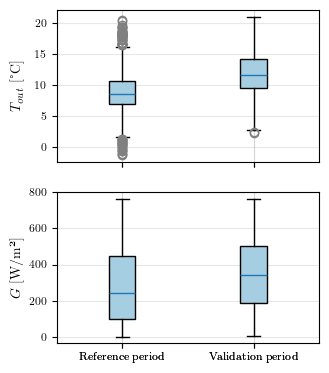

In [15]:
temps = [
    (opt_weather["brick:Outside_Air_Temperature_Sensor"].dropna().values),
    (exp_weather["brick:Outside_Air_Temperature_Sensor"].dropna().values),
]
si = [
    (opt_weather["brick:Solar_Irradiance_Sensor"].dropna().values),
    (exp_weather["brick:Solar_Irradiance_Sensor"].dropna().values),
]
fig, axs = plt.subplots(
    nrows=2, figsize=pf.get_figure_size("single", height=11), sharex=True
)
axs: list[plt.Axes]

flierprops = dict(marker='o', markeredgecolor='grey')

axs[0].boxplot(
    temps,
    widths=0.2,
    flierprops=flierprops,
    patch_artist=True,  # fill with color
    tick_labels=["Reference period", "Validation period"],
    # showfliers=False
)
axs[0].set_ylabel("$T_{out}$ [°C]")
# axs[0].set_ybound(lower=0)

axs[1].boxplot(
    si,
    widths=0.2,
    flierprops=flierprops,
    patch_artist=True,  # fill with color
    tick_labels=["Reference period", "Validation period"],
    # showfliers=False
)
axs[1].set_ylabel("$G$  [W/m²]")
fig.align_ylabels()
fig.savefig("figs/SAT paper/weather_boxplot.pdf", dpi=300, bbox_inches="tight")


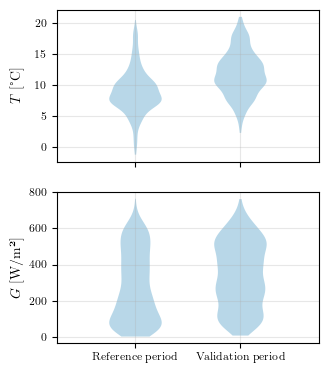

In [16]:
def set_axis_style(ax, labels):
    ax.set_xticks(np.arange(1, len(labels) + 1), labels=labels)
    ax.set_xlim(0.25, len(labels) + 0.75)

def change_parts(parts):
    for key in parts.keys():
        if key=='bodies':
            for pc in parts[key]:
                pc.set_facecolor("C0")
                # pc.set_edgecolor('black')
                pc.set_alpha(0.8)
        else:
            parts[key].set_color("C1")
        

temps = [
    (opt_weather["brick:Outside_Air_Temperature_Sensor"].dropna().values),
    (exp_weather["brick:Outside_Air_Temperature_Sensor"].dropna().values),
]
si = [
    (opt_weather["brick:Solar_Irradiance_Sensor"].dropna().values),
    (exp_weather["brick:Solar_Irradiance_Sensor"].dropna().values),
]
fig, axs = plt.subplots(
    nrows=2, figsize=pf.get_figure_size("single", height=11), sharex=True
)
axs: list[plt.Axes]

flierprops = dict(marker='o', markeredgecolor='grey')

parts = axs[0].violinplot(
    temps,
    showextrema=False,
    # widths=0.2,
    # flierprops=flierprops,
    # patch_artist=True,  # fill with color
    # tick_labels=["Reference period", "Validation period"],
    # showfliers=False
)
change_parts(parts)
axs[0].set_ylabel("$T$ [°C]")
# axs[0].set_ybound(lower=0)

parts = axs[1].violinplot(
    si,
    showextrema=False,
    # widths=0.2,
    # flierprops=flierprops,
    # patch_artist=True,  # fill with color
    # tick_labels=["Reference period", "Validation period"],
    # showfliers=False
)
axs[1].set_ylabel("$G$  [W/m²]")
set_axis_style(axs[1],["Reference period", "Validation period"])
change_parts(parts)
fig.align_ylabels()
fig.savefig("figs/SAT paper/weather_violin.pdf", dpi=300, bbox_inches="tight")


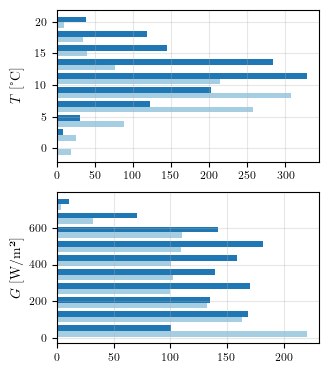

In [17]:
def set_axis_style(ax, labels):
    ax.set_xticks(np.arange(1, len(labels) + 1), labels=labels)
    ax.set_xlim(0.25, len(labels) + 0.75)

def change_parts(parts):
    for key in parts.keys():
        if key=='bodies':
            for pc in parts[key]:
                pc.set_facecolor("C0")
                # pc.set_edgecolor('black')
                pc.set_alpha(0.8)
        else:
            parts[key].set_color("C1")
        

temps = [
    (opt_weather["brick:Outside_Air_Temperature_Sensor"].dropna().values),
    (exp_weather["brick:Outside_Air_Temperature_Sensor"].dropna().values),
]
si = [
    (opt_weather["brick:Solar_Irradiance_Sensor"].dropna().values),
    (exp_weather["brick:Solar_Irradiance_Sensor"].dropna().values),
]
fig, axs = plt.subplots(
    nrows=2, figsize=pf.get_figure_size("single", height=11)
)
axs: list[plt.Axes]

flierprops = dict(marker='o', markeredgecolor='grey')

parts = axs[0].hist(
    temps,
    # bins=20,
    orientation='horizontal',
    # widths=0.2,
    # flierprops=flierprops,
    # patch_artist=True,  # fill with color
    # tick_labels=["Reference period", "Validation period"],
    # showfliers=False
)
axs[0].set_ylabel("$T$ [°C]")
# axs[0].set_ybound(lower=0)

parts = axs[1].hist(
    si,
    orientation='horizontal',
    # bins=20
    # widths=0.2,
    # flierprops=flierprops,
    # patch_artist=True,  # fill with color
    # tick_labels=["Reference period", "Validation period"],
    # showfliers=False
)
axs[1].set_ylabel("$G$  [W/m²]")
# set_axis_style(axs[1],["Reference period", "Validation period"])
fig.align_ylabels()
fig.savefig("figs/SAT paper/weather_hist.pdf", dpi=300, bbox_inches="tight")


In [18]:
# Calculate mean pr. day:
dh_opt = (opt_weather["brick:Outside_Air_Temperature_Sensor"]).resample('24h').mean()
dh_exp = (exp_weather["brick:Outside_Air_Temperature_Sensor"]).resample('24h').mean()

In [19]:
# Calculate solar irradiance pr. day:
solar_opt = (opt_weather["brick:Solar_Irradiance_Sensor"]).resample('24h').mean()
solar_exp = (exp_weather["brick:Solar_Irradiance_Sensor"]).resample('24h').mean()

In [20]:
px.bar(dh_opt)

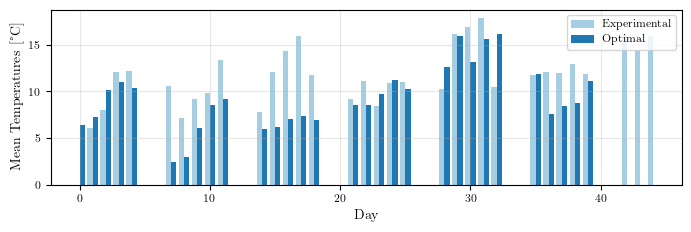

In [21]:
bar_width = 0.4

tick_distance = 2

opt_dates = dh_opt.index
opt_x = np.arange(len(opt_dates))
exp_dates = dh_exp.index
exp_x = np.arange(len(exp_dates))

fig, ax = plt.subplots(figsize=pf.get_figure_size())
ax.bar(exp_x +1 - bar_width/2, dh_exp.values, width=bar_width, label="Experimental")
ax.bar(opt_x + bar_width/2, dh_opt.values, width=bar_width, label="Optimal")

# ax.set_xticks(opt_x[::tick_distance])
# ax.set_xticklabels([date.strftime('%m-%d') for date in opt_dates[::tick_distance]])
ax.set_xlabel("Day")
ax.set_ylabel("Mean Temperatures [°C]")
ax.legend()
plt.tight_layout()
plt.show()

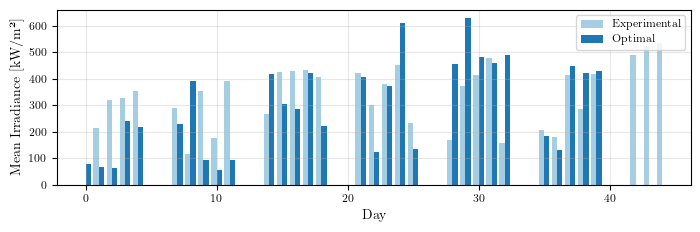

In [22]:

bar_width = 0.4

tick_distance = 2

opt_dates = solar_opt.index
opt_x = np.arange(len(opt_dates))
exp_dates = solar_exp.index
exp_x = np.arange(len(exp_dates))

fig, ax = plt.subplots(figsize=pf.get_figure_size())
ax.bar(exp_x + 1 - bar_width/2, solar_exp.values, width=bar_width, label="Experimental")
ax.bar(opt_x + bar_width/2, solar_opt.values, width=bar_width, label="Optimal")

# ax.set_xticks(opt_x[::tick_distance])
# ax.set_xticklabels([date.strftime('%m-%d') for date in opt_dates[::tick_distance]])
ax.set_xlabel("Day")
ax.set_ylabel("Mean Irradiance [kW/m²]")
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
window = 5

# Aggregate daily means
opt_temp = opt_weather["brick:Outside_Air_Temperature_Sensor"].resample('24h').mean()
opt_irr = opt_weather["brick:Solar_Irradiance_Sensor"].resample('24h').mean()
exp_temp = exp_weather["brick:Outside_Air_Temperature_Sensor"].resample('24h').mean()
exp_irr = exp_weather["brick:Solar_Irradiance_Sensor"].resample('24h').mean()

# Normalize each feature (z-score normalization)
all_temp = pd.concat([opt_temp, exp_temp])
all_irr = pd.concat([opt_irr, exp_irr])

opt_temp_norm = (opt_temp - all_temp.mean()) / all_temp.std()
opt_irr_norm = (opt_irr - all_irr.mean()) / all_irr.std()
exp_temp_norm = (exp_temp - all_temp.mean()) / all_temp.std()
exp_irr_norm = (exp_irr - all_irr.mean()) / all_irr.std()

opt_arr = np.column_stack([opt_temp_norm.values, opt_irr_norm.values])
exp_arr = np.column_stack([exp_temp_norm.values, exp_irr_norm.values])

dists = []
opt_starts = []
exp_starts = []

for i in range(len(opt_arr) - window + 1):
    opt_window = opt_arr[i:i+window]
    for j in range(len(exp_arr) - window + 1):
        # Only compare if both start days are a Monday
        if opt_temp.index[i].weekday() != 0 or exp_temp.index[j].weekday() != 0:
            continue
        exp_window = exp_arr[j:j+window]
        dist = np.linalg.norm(opt_window - exp_window)
        
        dists.append(dist)
        opt_starts.append(i)
        exp_starts.append(j)

# Sort the distances and find the minimum
sorted_indices = np.argsort(dists)
dists = np.array(dists)[sorted_indices]
opt_starts = np.array(opt_starts)[sorted_indices]
exp_starts = np.array(exp_starts)[sorted_indices]

min_dist = dists[[0, 1]]
best_opt_start = opt_starts[[0, 1]]
best_exp_start = exp_starts[[0, 1]]

for i in range(len(min_dist)):
    if i == 0:
        opt_days = opt_temp.index[best_opt_start[i]:best_opt_start[i]+window]
        exp_days = exp_temp.index[best_exp_start[i]:best_exp_start[i]+window]
    else:
        opt_days = opt_days.append(opt_temp.index[best_opt_start[i]:best_opt_start[i]+window])
        exp_days = exp_days.append(exp_temp.index[best_exp_start[i]:best_exp_start[i]+window])

print("Most similar 5-day period in optimal data:", [d.date() for d in opt_days])
print("Most similar 5-day period in experimental data:", [d.date() for d in exp_days])
print(f"Total normalized distance: {min_dist}")

Most similar 5-day period in optimal data: [datetime.date(2023, 4, 10), datetime.date(2023, 4, 11), datetime.date(2023, 4, 12), datetime.date(2023, 4, 13), datetime.date(2023, 4, 14), datetime.date(2023, 4, 24), datetime.date(2023, 4, 25), datetime.date(2023, 4, 26), datetime.date(2023, 4, 27), datetime.date(2023, 4, 28)]
Most similar 5-day period in experimental data: [datetime.date(2025, 4, 7), datetime.date(2025, 4, 8), datetime.date(2025, 4, 9), datetime.date(2025, 4, 10), datetime.date(2025, 4, 11), datetime.date(2025, 3, 24), datetime.date(2025, 3, 25), datetime.date(2025, 3, 26), datetime.date(2025, 3, 27), datetime.date(2025, 3, 28)]
Total normalized distance: [1.98558959 2.15840094]


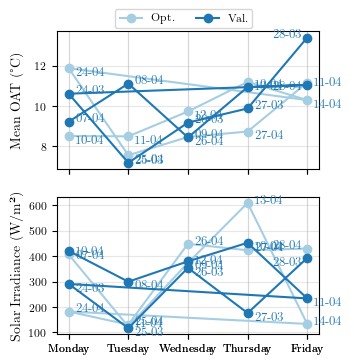

In [24]:
# Plot the two most similar 5-day periods together

fig, axs = plt.subplots(2, 1, figsize=pf.get_figure_size("single",height=10), sharex=True)

axs : list[plt.Axes]
# x = np.arange(len(opt_days)) + 1

x = opt_days.day_name()
# Plot temperature
axs[0].plot(x, opt_temp.loc[opt_days], marker='o', label='Optimal')
axs[0].plot(x, exp_temp.loc[exp_days], marker='o', label='Experimental')
axs[0].set_ylabel("Mean OAT (°C)")

# axs[0].legend(loc="upper center", ncols=2, bbox_to_anchor=(0.5, 1.19), frameon=False)

# Plot irradiance
axs[1].plot(x, opt_irr.loc[opt_days], marker='o', label='Optimal')
axs[1].plot(x, exp_irr.loc[exp_days], marker='o', label='Experimental')
axs[1].set_ylabel("Solar Irradiance (W/m²)")

axs[1].set_xticks(x)

# Annotate each point with its date
for i, (opt_date, exp_date) in enumerate(zip(opt_days, exp_days)):
    # axs[0].text(x[i], opt_temp.loc[opt_date] + 0.30, opt_date.strftime('%d-%m'), ha='left', va='center',fontsize=9, color='C1')
    # axs[0].text(x[i], exp_temp.loc[exp_date] - 0.30, exp_date.strftime('%d-%m'), ha='left', va='center',fontsize=9, color='C1')
    # axs[1].text(x[i], opt_irr.loc[opt_date] + 8, opt_date.strftime('%d-%m'), ha='left', va='center',fontsize=9, color='C1')
    # axs[1].text(x[i], exp_irr.loc[exp_date] - 8, exp_date.strftime('%d-%m'), ha='left', va='center',fontsize=9, color='C1')
    if i == len(x) - 1:
        ha = 'right'
        x_offset = -3
    else:
        ha = 'left'
        x_offset = 5
    axs[0].annotate(opt_date.strftime('%d-%m'), (x[i], opt_temp.loc[opt_date]), xytext=(x_offset,-5), horizontalalignment = ha, textcoords='offset points', fontsize=9, color='C1')
    axs[0].annotate(exp_date.strftime('%d-%m'), (x[i], exp_temp.loc[exp_date]), xytext=(x_offset,0), horizontalalignment = ha, textcoords='offset points', fontsize=9, color='C1')
    axs[1].annotate(opt_date.strftime('%d-%m'), (x[i], opt_irr.loc[opt_date]), xytext=(x_offset,0), horizontalalignment = ha, textcoords='offset points', fontsize=9, color='C1')
    axs[1].annotate(exp_date.strftime('%d-%m'), (x[i], exp_irr.loc[exp_date]), xytext=(x_offset,-5), horizontalalignment = ha, textcoords='offset points', fontsize=9, color='C1')

fig.align_ylabels()
fig.legend(["Opt.", "Val."],loc="upper center", ncols=2, bbox_to_anchor=(0.5, 0.95))
plt.savefig("figs/SAT paper/weather_comparison.pdf")

## Compare modes

In [25]:
from SAT_classes import AHU, Zone

# First, we need to instantiate zones:
opt_zones = []
for i, col in enumerate(zone_data_opt.columns.levels[0]):
    zone = Zone(col)
    zone.add_data(zone_data_opt[col])
    progress = (i+1)/len(zone_data_opt.columns.levels[0])*100
    print(f"Progress: {progress:.2f}%", end="\r")
    if not zone.check_data_point():
        print(f"Zone {zone.name} has missing data points - removing it from analysis\n")
        continue
    zone.find_modes()
    opt_zones.append(zone)

exp_zones = []
for i, col in enumerate(zone_data_exp.columns.levels[0]):
    zone = Zone(col)
    zone.add_data(zone_data_exp[col])
    progress = (i+1)/len(zone_data_exp.columns.levels[0])*100
    print(f"Progress: {progress:.2f}%", end="\r")
    if not zone.check_data_point():
        print(f"Zone {zone.name} has missing data points - removing it from analysis\n")
        continue
    zone.find_modes()
    exp_zones.append(zone)




c:\Users\evifj\git\DDB-C-Dataplatform-Analysis\SAT_classes.py:197: RuntimeWarning:

divide by zero encountered in scalar divide



Zone R00.16 has missing data points - removing it from analysis

Zone R00.52 has missing data points - removing it from analysis

Zone R00.55 has missing data points - removing it from analysis

Zone R00.56 has missing data points - removing it from analysis

Zone R00.57 has missing data points - removing it from analysis

Zone R00.58 has missing data points - removing it from analysis

Zone R00.59 has missing data points - removing it from analysis

Zone R00.60 has missing data points - removing it from analysis

Zone R00.61 has missing data points - removing it from analysis



c:\Users\evifj\git\DDB-C-Dataplatform-Analysis\SAT_classes.py:197: RuntimeWarning:

divide by zero encountered in scalar divide



c:\Users\evifj\git\DDB-C-Dataplatform-Analysis\SAT_classes.py:197: RuntimeWarning:

divide by zero encountered in scalar divide



c:\Users\evifj\git\DDB-C-Dataplatform-Analysis\SAT_classes.py:197: RuntimeWarning:

divide by zero encountered in scalar divide

c:\Users\evifj\git\DDB-C-Dataplatform-Analysis\SAT_classes.py:197: RuntimeWarning:

divide by zero encountered in scalar divide

c:\Users\evifj\git\DDB-C-Dataplatform-Analysis\SAT_classes.py:197: RuntimeWarning:

divide by zero encountered in scalar divide



...

Zone R04.53 has missing data points - removing it from analysis

Zone R04.55 has missing data points - removing it from analysis

Zone R04.56 has missing data points - removing it from analysis

Zone R04.57 has missing data points - removing it from analysis

Zone R04.58 has missing data points - removing it from analysis

Zone R04.59 has missing data points - removing it from analysis

Zone R04.60 has missing data points - removing it from analysis

Zone R04.61 has missing data points - removing it from analysis



c:\Users\evifj\git\DDB-C-Dataplatform-Analysis\SAT_classes.py:197: RuntimeWarning:

divide by zero encountered in scalar divide



Zone R05.53 has missing data points - removing it from analysis

Zone R05.55 has missing data points - removing it from analysis

Zone R05.56 has missing data points - removing it from analysis

Zone R05.57 has missing data points - removing it from analysis

Zone R05.58 has missing data points - removing it from analysis

Zone R05.59 has missing data points - removing it from analysis

Zone R05.60 has missing data points - removing it from analysis

Zone R05.61 has missing data points - removing it from analysis



c:\Users\evifj\git\DDB-C-Dataplatform-Analysis\SAT_classes.py:197: RuntimeWarning:

divide by zero encountered in scalar divide



Zone R06.53 has missing data points - removing it from analysis

Zone R06.55 has missing data points - removing it from analysis

Zone R06.56 has missing data points - removing it from analysis

Zone R06.57 has missing data points - removing it from analysis

Zone R06.58 has missing data points - removing it from analysis

Zone R06.59 has missing data points - removing it from analysis

Zone R06.60 has missing data points - removing it from analysis

Zone R06.61 has missing data points - removing it from analysis

Zone R07.53 has missing data points - removing it from analysis

Zone R07.55 has missing data points - removing it from analysis

Zone R07.56 has missing data points - removing it from analysis

Zone R07.57 has missing data points - removing it from analysis

Zone R07.58 has missing data points - removing it from analysis

Zone R07.59 has missing data points - removing it from analysis

Zone R07.60 has missing data points - removing it from analysis

Zone R07.61 has missing d

In [26]:
# We'll check if all zones are in both datasets - if not, there might be something wrong
exp_names = set([z.name for z in exp_zones])
opt_names = set([z.name for z in opt_zones])
print("Missing zones in exp_names:", opt_names.difference(exp_names) if opt_names.difference(exp_names) != set() else 0)
print("Missing zones in opt_names:", exp_names.difference(opt_names) if exp_names.difference(opt_names) != set() else 0)

Missing zones in exp_names: 0
Missing zones in opt_names: 0


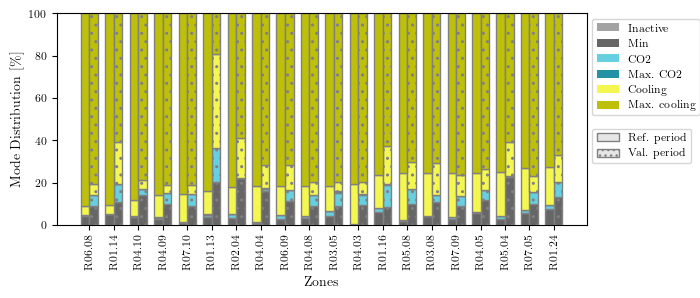

In [27]:
opt_zones = sorted(opt_zones, key=lambda x: x.summarize_modes()["temp-max"], reverse=True)
opt_plot_zones = opt_zones[0:20]

exp_zones = sorted(exp_zones, key=lambda x: x.summarize_modes()["temp-max"], reverse=True)
# exp_plot_zones = exp_zones[0:20]
exp_plot_zones = []
for zone in opt_plot_zones:
    # Find the corresponding zone in the experimental data
    if zone.name in [z.name for z in exp_zones]:
        # Append the zone from experimental data
        exp_plot_zones.append([z for z in exp_zones if z.name == zone.name][0])
    else:
        # Make a "dummy zone" with no data - will occur blank in the plot
        non_zone = Zone(zone.name)
        non_zone.add_data(pd.DataFrame(index=opt_idx, columns=["mode"]))
        non_zone.data["mode"] = pd.NA
        exp_plot_zones.append(non_zone)

f.compare_modes(opt_plot_zones, exp_plot_zones, "Modes_Comparison", hatch='..', labels=["Ref. period", "Val. period"])

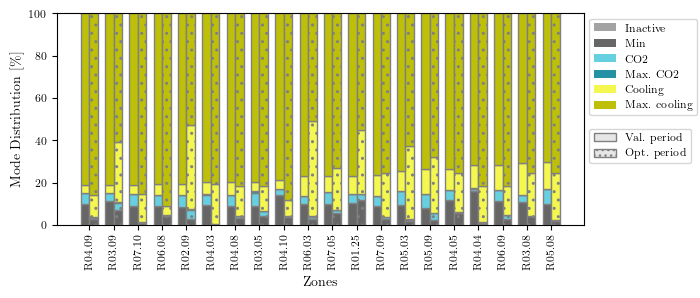

In [28]:
exp_plot_zones = exp_zones[0:20]
opt_plot_zones = []
for zone in exp_plot_zones:
    # Find the corresponding zone in the experimental data
    if zone.name in [z.name for z in exp_zones]:
        # Append the zone from experimental data
        opt_plot_zones.append([z for z in opt_zones if z.name == zone.name][0])

f.compare_modes(exp_plot_zones, opt_plot_zones, "Modes_Comparison_Reversed", hatch='..', labels=["Val. period", "Opt. period"])

In [29]:
# Get room area from GraphDB
query = """
PREFIX brick: <https://brickschema.org/schema/Brick#>
PREFIX ref: <https://brickschema.org/schema/ref#>
PREFIX bot: <https://w3id.org/bot#>
PREFIX ex: <https://example.com/ex#>
select distinct ?roomNumber ?volume ?area where {
	?zone a bot:Space .
    ?zone ex:roomNumber ?roomNumber .
    ?zone brick:area/brick:value ?area .
    ?zone brick:volume/brick:value ?volume .
}
"""
res = f.run_query(repository, query, base_url = base_url, token = token)
res = f.fix_res(res, "roomNumber", ["area", "volume"])
for zone in exp_zones:
    zone: Zone
    if zone.name not in res.keys():
        continue
    area = res[zone.name][0]["area"]
    volume = res[zone.name][0]["volume"]
    zone.set_area(float(area))
    zone.set_volume(float(volume))
    # Calculate the heat load for each zone ()
    zone.calculate_heat_load()

for zone in opt_zones:
    zone: Zone
    if zone.name not in res.keys():
        continue
    area = res[zone.name][0]["area"]
    volume = res[zone.name][0]["volume"]
    zone.set_area(float(area))
    zone.set_volume(float(volume))
    # Calculate the heat load for each zone ()
    zone.calculate_heat_load()

In [30]:
idx = np.random.randint(0, len(opt_zones))
px.line(opt_zones[idx].data,y=["brick:Zone_Air_Temperature_Sensor", "brick:Zone_Air_Cooling_Temperature_Setpoint"], title=f"Zone {opt_zones[idx].name} - Original SAT", labels={"value":"Temperature [°C]", "index":"Time", "variable":"Sensor"}).show()

## Compare DH ($f_2$)

In [105]:
DH_opt = 0
DH_exp = 0
total_area = 0
for zone in exp_zones:
    T_above_setpoint = zone.data["brick:Zone_Air_Temperature_Sensor"] - zone.data["brick:Zone_Air_Cooling_Temperature_Setpoint"]
    T_above_setpoint.clip(lower=0, inplace=True)
    total_area += zone.area
    
    DH_exp += (T_above_setpoint*freq).sum()*zone.area # K*h*m2

for zone in opt_zones:
    T_above_setpoint = zone.data["brick:Zone_Air_Temperature_Sensor"] - zone.data["brick:Zone_Air_Cooling_Temperature_Setpoint"]
    T_above_setpoint.clip(lower=0, inplace=True)
    
    DH_opt += (T_above_setpoint*freq).sum()*zone.area # K*h*m2

DH_opt = DH_opt/total_area # K*h
DH_exp = DH_exp/total_area # K*h
DH_exp_norm = DH_exp*opt_weather["brick:Solar_Irradiance_Sensor"].mean()/exp_weather["brick:Solar_Irradiance_Sensor"].mean() # Corrected for difference in solar irradiance

print("Degreehours in optimization period:\t", round(DH_opt,1))
print("Degreehours in experiment period:\t", round(DH_exp,1))
print("Normalized degreehours in experiment period:\t", round(DH_exp_norm,1))

print(f"Reduction: {round(100*(DH_opt-DH_exp)/DH_opt, 1)} %")

Degreehours in optimization period:	 102.5
Degreehours in experiment period:	 77.2
Normalized degreehours in experiment period:	 63.1
Reduction: 24.7 %


In [106]:
opt_timesteps = opt_zones[0].data["brick:Zone_Air_Temperature_Sensor"].notna().sum()
exp_timesteps = exp_zones[0].data["brick:Zone_Air_Temperature_Sensor"].notna().sum()
print("Hours in reference period: ",opt_timesteps*freq)
print("Hours in validation period:",exp_timesteps*freq)

Hours in reference period:  268.25
Hours in validation period: 319.5


In [107]:
DH_opt_rel = DH_opt/(opt_timesteps*freq)
DH_exp_rel = DH_exp/(exp_timesteps*freq)
print("Degreehours pr. hour in optimization period:\t", round(DH_opt_rel,2))
print("Degreehours pr. hour in experiment period:\t", round(DH_exp_rel,2))

print(f"Reduction: {round(100*(DH_opt_rel-DH_exp_rel)/DH_opt_rel, 1)} %")

Degreehours pr. hour in optimization period:	 0.38
Degreehours pr. hour in experiment period:	 0.24
Reduction: 36.7 %


### DH in upper quantile zones
Here, we evaluate the benefits in the worst-behaving zones in both scenarios, to see if they have improved more or less than the rest

In [34]:
DH_list_exp = np.array([])
DH_list_opt = np.array([])
areas_exp = np.array([])
areas_opt = np.array([])
names_exp = np.array([])
names_opt = np.array([])
for zone in exp_zones:
    T_above_setpoint = zone.data["brick:Zone_Air_Temperature_Sensor"] - zone.data["brick:Zone_Air_Cooling_Temperature_Setpoint"]
    T_above_setpoint.clip(lower=0, inplace=True)
    
    DH_list_exp = np.append(DH_list_exp, (T_above_setpoint*freq).mean()*zone.area) # K*h*m2
    areas_exp = np.append(areas_exp, zone.area)
    names_exp = np.append(names_exp, zone.name)

for zone in opt_zones:
    T_above_setpoint = zone.data["brick:Zone_Air_Temperature_Sensor"] - zone.data["brick:Zone_Air_Cooling_Temperature_Setpoint"]
    T_above_setpoint.clip(lower=0, inplace=True)
    
    DH_list_opt = np.append(DH_list_opt, (T_above_setpoint*freq).mean()*zone.area) # K*h*m2
    areas_opt = np.append(areas_opt, zone.area)
    names_opt = np.append(names_opt, zone.name)

sort_idx_exp = np.argsort(DH_list_exp)
sort_idx_opt = np.argsort(DH_list_opt)

DH_list_exp = DH_list_exp[sort_idx_exp][::-1]*opt_weather["brick:Solar_Irradiance_Sensor"].mean()/exp_weather["brick:Solar_Irradiance_Sensor"].mean()/areas_exp.mean()
DH_list_opt = DH_list_opt[sort_idx_opt][::-1]/areas_opt.mean()
areas_exp = areas_exp[sort_idx_exp][::-1]
areas_opt = areas_opt[sort_idx_opt][::-1]
names_exp = names_exp[sort_idx_exp][::-1]
names_opt = names_opt[sort_idx_opt][::-1]



In [35]:
# Top q% zones
q = 1
idx = int(round(len(exp_zones)*q))
DH_list_exp = DH_list_exp[:idx]
DH_list_opt = DH_list_opt[:idx]
areas_exp = areas_exp[:idx]
areas_opt = areas_opt[:idx]
names_exp = names_exp[:idx]
names_opt = names_opt[:idx]

In [36]:
DH_exp_rel_25 = ((DH_list_exp)).mean()
DH_opt_rel_25 = ((DH_list_opt)).mean()
print("Mean temperature violation in optimization period:\t", round(DH_opt_rel_25,5))
print("Mean temperature violation in experiment period:\t", round(DH_exp_rel_25,5))

print(f"Reduction: {round(100*(DH_opt_rel_25-DH_exp_rel_25)/DH_opt_rel_25, 1)} %")

Mean temperature violation in optimization period:	 0.09553
Mean temperature violation in experiment period:	 0.04977
Reduction: 47.9 %


In [37]:
ys=[DH_list_opt, DH_list_exp]
fig = px.line(x=range(idx),y=ys.copy())
for i, name in enumerate(names_opt):
    x_text = i
    y_text = ys[0][i]
    fig.add_annotation(x=x_text, y=y_text, text=name)
    
for i, name in enumerate(names_exp):
    x_text = i
    y_text = ys[1][i]
    fig.add_annotation(x=x_text, y=y_text, text=name)

fig.show()

In [38]:
zone = [zone for zone in opt_zones if zone.name == names_opt[0]][0]
px.line(zone.data[["brick:Zone_Air_Temperature_Sensor","brick:Zone_Air_Cooling_Temperature_Setpoint"]]).show()
print(zone.name)
mean_temp_violation = (zone.data["brick:Zone_Air_Temperature_Sensor"]-zone.data["brick:Zone_Air_Cooling_Temperature_Setpoint"]).clip(0).mean()
print('Mean temperature violation:', mean_temp_violation)
zone_DH = (zone.data["brick:Zone_Air_Temperature_Sensor"]-zone.data["brick:Zone_Air_Cooling_Temperature_Setpoint"]).clip(0).sum()*freq
print('Zone DHs:', zone_DH)
print('')
print("zone area:",zone.area)
print("average zone area:", areas_opt.mean())
print('')
print("corrected mean temperature violation:", mean_temp_violation*zone.area/areas_opt.mean())
print("corrected DH:", zone_DH*zone.area/areas_opt.mean())

R02.01
Mean temperature violation: 0.7770076110593354
Zone DHs: 208.4322916666667

zone area: 263.219208039233
average zone area: 42.24376069699037

corrected mean temperature violation: 4.841503801958281
corrected DH: 1298.7333948753087


In [39]:
names_opt

array(['R02.01', 'R05.01', 'R04.01', 'R01.29', 'R01.30', 'R06.01',
       'R07.01', 'R01.14', 'R05.07', 'R01.17', 'R01.13', 'R01.16',
       'R06.08', 'R01.26', 'R03.05', 'R03.01', 'R02.07', 'R07.09',
       'R07.05', 'R03.07', 'R06.05', 'R04.05', 'R04.08', 'R07.08',
       'R01.15', 'R03.08', 'R04.03', 'R04.07', 'R05.08', 'R02.05',
       'R07.10', 'R06.09', 'R04.09', 'R07.03', 'R05.05', 'R01.24',
       'R02.03', 'R01.23', 'R02.08', 'R01.10', 'R01.12', 'R01.21',
       'R01.03', 'R01.11', 'R03.09', 'R05.09', 'R01.25', 'R05.03',
       'R04.04', 'R02.04', 'R03.03', 'R01.22', 'R02.09', 'R06.03',
       'R04.10', 'R05.04', 'R01.07', 'R00.17', 'R01.06', 'R03.04',
       'R01.02', 'R01.20', 'R00.23', 'R06.04', 'R07.11', 'R06.10',
       'R06.07', 'R01.09', 'R07.04', 'R07.07', 'R00.05', 'R01.08',
       'R05.10', 'R02.10', 'R04.51', 'R01.01', 'R03.10', 'R05.51',
       'R00.20', 'R07.12', 'R02.51', 'R07.51', 'R00.28', 'R00.10',
       'R00.08', 'R00.09', 'R00.18', 'R00.27', 'R00.19', 'R00.

## Compare energy

In [40]:
AHUs = ["HTRK_VEN01", "HTR9_VEN01"]
ahu_list_exp = []
ahu_list_opt = []

for name in AHUs:
   ahu_exp = AHU(name)
   ahu_exp.add_data(ahu_data_exp[name])
   ahu_list_exp.append(ahu_exp)

   ahu_opt = AHU(name)
   ahu_opt.add_data(ahu_data_opt[name])
   ahu_list_opt.append(ahu_opt)

In [41]:

rho = 1.204
c_p = 1006.0

for i, exp_ahu in enumerate(ahu_list_exp):

    
    opt_ahu = ahu_list_opt[i]
    exp_ahu: AHU
    opt_ahu: AHU

    if i == 0:
        exp_q_fan = exp_ahu.data["brick:Electric_Power_Sensor"].copy()
        opt_q_fan = opt_ahu.data["brick:Electric_Power_Sensor"].copy()
        exp_q_hc = exp_ahu.data["brick:Heating_Thermal_Power_Sensor"].copy()
        # exp_q_hc_c = exp_q_hc - (exp_ahu.data["brick:Supply_Air_Flow_Sensor"]/3600)*rho*c_p*(opt_ahu.data["brick:Outside_Air_Temperature_Sensor"].values-exp_ahu.data["brick:Outside_Air_Temperature_Sensor"])/1000
        opt_q_hc = opt_ahu.data["brick:Heating_Thermal_Power_Sensor"].copy()
        exp_q_cc = exp_ahu.data["brick:Cooling_Thermal_Power_Sensor"].copy()/3
        opt_q_cc = opt_ahu.data["brick:Cooling_Thermal_Power_Sensor"].copy()/3

    else:
        exp_q_fan += exp_ahu.data["brick:Electric_Power_Sensor"].copy()
        opt_q_fan += opt_ahu.data["brick:Electric_Power_Sensor"].copy()
        # exp_q_hc_c  += exp_ahu.data["brick:Heating_Thermal_Power_Sensor"].copy()
        opt_q_hc  += opt_ahu.data["brick:Heating_Thermal_Power_Sensor"].copy()
        exp_q_cc  += exp_ahu.data["brick:Cooling_Thermal_Power_Sensor"].copy()/3
        opt_q_cc  += opt_ahu.data["brick:Cooling_Thermal_Power_Sensor"].copy()/3
    

print("Average measured fan energy in optimization period: ",
    format(opt_q_fan.mean(), '0.2'), "[kW]")
print("Average measured fan energy in experiment period:   ",
    format(exp_q_fan.mean(), '0.2'), "[kW]")
print("Average measured heating coil energy in optimization period: ",
    format(opt_q_hc.mean(), '0.2'), "[kW]")
print("Average measured heating coil energy in experiment period:   ",
    format(exp_q_hc.mean(), '0.2'), "[kW]")
# print("Average measured heating coil energy in experiment period (corrected for OAT):   ",
#     format(exp_q_hc_c.mean(), '0.2'), "[kW]")
print("Average measured cooling energy in optimization period: ",
    format(opt_q_cc.mean(), '0.2'), "[kW]")
print("Average measured cooling energy in experiment period:   ",
    format(exp_q_cc.mean(), '0.2'), "[kW]")

Average measured fan energy in optimization period:  1.8e+01 [kW]
Average measured fan energy in experiment period:    1.4e+01 [kW]
Average measured heating coil energy in optimization period:  7.2 [kW]
Average measured heating coil energy in experiment period:    0.035 [kW]
Average measured cooling energy in optimization period:  -0.36 [kW]
Average measured cooling energy in experiment period:    -0.58 [kW]


In [42]:
# Compare radiator heating:
exp_q_sh = heating_data_exp
opt_q_sh = heating_data_opt

In [43]:
print("Average measured space heating energy in optimization period: ",format(opt_q_sh.mean(),'0.2e'),"[kW]")
print("Average measured space heating energy in experiment period:   ",format(exp_q_sh.mean(),'0.2e'),"[kW]")

Average measured space heating energy in optimization period:  9.92e+00 [kW]
Average measured space heating energy in experiment period:    8.63e+00 [kW]


In [44]:
pef = True

if pef:
    q_tot_exp = 1.9*exp_q_fan + 0.85*(exp_q_hc + exp_q_sh)
    q_tot_opt = 1.9*opt_q_fan + 0.85*(opt_q_hc + opt_q_sh)
else:
    q_tot_exp = exp_q_fan + exp_q_hc + exp_q_sh
    q_tot_opt = opt_q_fan + opt_q_hc + opt_q_sh


print("Average measured total energy in optimization period: " ,format(q_tot_opt.mean(),'0.3'),"[kW]")
print("Average measured total energy in experiment period:   " ,format(q_tot_exp.mean(),'0.3'),"[kW]")

Average measured total energy in optimization period:  49.1 [kW]
Average measured total energy in experiment period:    33.2 [kW]


In [45]:
q_tot_opt.sum()

np.float64(52645.75430311356)

### Compare delivered cooling

In [46]:
exp_q_cool = pd.Series(index=exp_zones[0].data.index, data=0, name="Ventilation Heat Flow (val.) [kW]")
opt_q_cool = pd.Series(index=opt_zones[0].data.index, data=0, name="Ventilation Heat Flow (opt.) [kW]")

c_p = 1006.0
rho = 1.204

for i, exp_zone in enumerate(exp_zones):
    exp_zone: Zone
    name = exp_zone.name
    
    opt_zone = [z for z in opt_zones if z.name == name][0]
    
    exp_q_cool += -(exp_zone.data["brick:Supply_Air_Flow_Sensor"]/3600 * rho  * c_p * (exp_zone.data["brick:Supply_Air_Temperature_Sensor"] - exp_zone.data["brick:Zone_Air_Temperature_Sensor"])/1000).fillna(0)
    opt_q_cool += -(opt_zone.data["brick:Supply_Air_Flow_Sensor"]/3600 * rho  * c_p * (opt_zone.data["brick:Supply_Air_Temperature_Sensor"] - opt_zone.data["brick:Zone_Air_Temperature_Sensor"])/1000).fillna(0)


In [47]:
exp_mask = (exp_q_cool != 0) & (exp_q_cool.notna())
opt_mask = (opt_q_cool != 0) & (opt_q_cool.notna())

opt_q_vent_tot = opt_q_cool.mean()
exp_q_vent_tot = exp_q_cool.mean()

print("Average delivered cooling energy in optimization period: ",round(opt_q_vent_tot,2),"[kW]")
print("Average delivered cooling energy in experiment period: ",round(exp_q_vent_tot,2),"[kW]")

Average delivered cooling energy in optimization period:  41.53 [kW]
Average delivered cooling energy in experiment period:  62.02 [kW]


In [48]:
Q_rel_opt = (q_tot_opt.sum()/opt_q_cool.sum())
Q_rel_exp = (q_tot_exp.sum()/exp_q_cool.sum())

print("Q_tot pr. delivered cooling in optimization period: ",round(Q_rel_opt,2),"[-]")
print("Q_tot pr. delivered cooling in experiment period: ",round(Q_rel_exp,2),"[-]")

Q_tot pr. delivered cooling in optimization period:  1.06 [-]
Q_tot pr. delivered cooling in experiment period:  0.53 [-]


In [49]:
(Q_rel_opt-Q_rel_exp)/(Q_rel_opt)

np.float64(0.49574568475986786)

In [50]:
from tabulate import tabulate
print("Energy style:")
print(
    tabulate(
        [
            [
                "Ref.",
                round(q_tot_opt.sum() * freq/1000,1),
                round(opt_q_cool.sum() * freq/1000,1),
                round(Q_rel_opt,2),
            ],
            [
                "Val.",
                round(q_tot_exp.sum() * freq/1000,1),
                round(exp_q_cool.sum() * freq/1000,1),
                round(Q_rel_exp,2),
            ],
        ],
        headers=["", "Q_tot [MWh]", "Q_c [MWh]", "SEC [%]"],
    )
)
print((Q_rel_opt-Q_rel_exp)/(Q_rel_opt))

Energy style:
        Q_tot [MWh]    Q_c [MWh]    SEC [%]
----  -------------  -----------  ---------
Ref.           13.2         12.5       1.06
Val.           10.6         19.8       0.53
0.49574568475986786


In [51]:
# Calculate a normalized energy use:
q_tot_exp_norm = (q_tot_exp.sum() * freq / 1000) * (opt_q_cool.sum() * freq / 1000) / (exp_q_cool.sum() * freq / 1000)


print("Energy style (normalized):")
print(
    tabulate(
        [
            [
                "Ref.",
                round(q_tot_opt.mean(),1),
                round(q_tot_opt.sum() * freq/1000,1),
                round(opt_q_cool.sum() * freq/1000,1),
                round(q_tot_opt.sum() * freq/1000,1),
            ],
            [
                "Val.",
                round(q_tot_exp.mean(),1),
                round(q_tot_exp.sum() * freq/1000,1),
                round(exp_q_cool.sum() * freq/1000,1),
                round(q_tot_exp_norm,1),
            ],
            [
                "Reduction:",
                round((q_tot_opt.mean()-q_tot_exp.mean())/(q_tot_opt.mean()),2),
                round((q_tot_opt.sum() * freq/1000-q_tot_exp.sum()* freq/1000)/(q_tot_opt.sum() * freq/1000),2),
                None,
                round((q_tot_opt.sum() * freq/1000-q_tot_exp_norm)/(q_tot_opt.sum() * freq/1000),2)
                                        ]
        ],
        headers=["", "Q_tot_mean [kW]", "Q_tot [MWh]", "Q_c [MWh]", "Q_tot_norm [MWh]"],
    )
)
print((q_tot_opt.sum() * freq/1000-q_tot_exp_norm)/(q_tot_opt.sum() * freq/1000))

Energy style (normalized):
              Q_tot_mean [kW]    Q_tot [MWh]    Q_c [MWh]    Q_tot_norm [MWh]
----------  -----------------  -------------  -----------  ------------------
Ref.                    49.1            13.2         12.5                13.2
Val.                    33.2            10.6         19.8                 6.6
Reduction:               0.32            0.2                              0.5
0.4957456847598679


In [52]:
print("Energy style:")
print(
    tabulate(
        [
            [
                "Ref.",
                round(q_tot_opt.sum() * freq/1000,1),
                round(opt_q_cool.sum() * freq/1000,1),
                round(Q_rel_opt,2),
            ],
            [
                "Val.",
                round(q_tot_exp.sum() * freq/1000,1),
                round(exp_q_cool.sum() * freq/1000,1),
                round(Q_rel_exp,2),
            ],
        ],
        headers=["", "Q_tot [MWh]", "Q_c [MWh]", "SEC [%]"],
    )
)
print((Q_rel_opt-Q_rel_exp)/(Q_rel_opt))

Energy style:
        Q_tot [MWh]    Q_c [MWh]    SEC [%]
----  -------------  -----------  ---------
Ref.           13.2         12.5       1.06
Val.           10.6         19.8       0.53
0.49574568475986786


In [53]:
# COP style:
print("COP style:")
print(
    tabulate(
        [
            [
                "Ref.",
                round(opt_q_cool.sum() * freq / 1000, 1),
                round(q_tot_opt.sum() * freq / 1000, 1),
                round(opt_q_cool.sum()/q_tot_opt.sum(), 2),
            ],
            [
                "Val.",
                round(exp_q_cool.sum() * freq / 1000, 1),
                round(q_tot_exp.sum() * freq / 1000, 1),
                round(exp_q_cool.sum()/q_tot_exp.sum(), 2),
            ],
        ],
        headers=["",
                 "Q_c [MWh]",
                 "Q_tot [MWh]",
                 "SEC [%]"],
    )
)
print((exp_q_cool.sum()/q_tot_exp.sum()-opt_q_cool.sum()/q_tot_opt.sum())/(opt_q_cool.sum()/q_tot_opt.sum()))

COP style:
        Q_c [MWh]    Q_tot [MWh]    SEC [%]
----  -----------  -------------  ---------
Ref.         12.5           13.2       0.95
Val.         19.8           10.6       1.88
0.9831263110238091


In [54]:
# Without heating:
print("Energy style (without space heating):")

new_q_rel_exp = (q_tot_exp-exp_q_sh).sum() / exp_q_cool.sum()
new_q_rel_opt = (q_tot_opt-opt_q_sh).sum() / opt_q_cool.sum()

print(
    tabulate(
        [
            [
                "Ref.",
                round((q_tot_opt-opt_q_sh).sum() * freq/1000,1),
                round(opt_q_cool.sum() * freq/1000,1),
                round(new_q_rel_opt,2),
            ],
            [
                "Val.",
                round((q_tot_exp-exp_q_sh).sum() * freq/1000,1),
                round(exp_q_cool.sum() * freq/1000,1),
                round(new_q_rel_exp,2),
            ],
            ["Improvement","","",f"{round(100*(new_q_rel_opt-new_q_rel_exp)/(new_q_rel_opt),1)} %"]
        ],
        headers=["", "Q_tot [MWh]", "Q_c [MWh]", "SEC [%]"],
    )
)
# print(round(100*(new_q_rel_opt-new_q_rel_exp)/(new_q_rel_opt),1), "%")

Energy style (without space heating):
             Q_tot [MWh]    Q_c [MWh]    SEC [%]
-----------  -------------  -----------  ---------
Ref.         10.5           12.5         0.84
Val.         7.8            19.8         0.39
Improvement                              53.1 %


In [55]:
# Without heating:
print("Energy style (normalized, without space heating):")

q_tot_exp_norm = ((q_tot_exp-exp_q_sh).sum() * freq / 1000) * (opt_q_cool.sum() * freq / 1000) / (exp_q_cool.sum() * freq / 1000)
# new_q_rel_exp = (q_tot_exp-exp_q_sh).sum()
q_tot_opt_norm = (q_tot_opt-opt_q_sh).sum() * freq / 1000

print(
    tabulate(
        [
            [
                "Ref.",
                round((q_tot_opt-opt_q_sh).sum() * freq/1000,1),
                round(opt_q_cool.sum() * freq/1000,1),
                round(q_tot_opt_norm,2),
            ],
            [
                "Val.",
                round((q_tot_exp-exp_q_sh).sum() * freq/1000,1),
                round(exp_q_cool.sum() * freq/1000,1),
                round(q_tot_exp_norm,2),
            ],
            ["Improvement","","",f"{round(100*(q_tot_opt_norm-q_tot_exp_norm)/(q_tot_opt_norm),1)} %"]
        ],
        headers=["", "Q_tot [MWh]", "Q_c [MWh]", "Q_tot_norm [MWh]"],
    )
)
# print(round(100*(new_q_rel_opt-new_q_rel_exp)/(new_q_rel_opt),1), "%")

Energy style (normalized, without space heating):
             Q_tot [MWh]    Q_c [MWh]    Q_tot_norm [MWh]
-----------  -------------  -----------  ------------------
Ref.         10.5           12.5         10.47
Val.         7.8            19.8         4.91
Improvement                              53.1 %


In [56]:
print("Performance improvement, sum (do not account for difference in dataset lengths):")
ref = q_tot_opt.sum()
val = q_tot_exp.sum()
print(f"{(ref-val)/ref:.2f}")

print("Performance improvement, mean (accounting for dataset length):")
ref = q_tot_opt.mean()
val = q_tot_exp.mean()
print(f"{(ref-val)/ref:.2f}")

print("Performance improvement, mean + G (accounting for dataset length and solar irradiance):")
ref = q_tot_opt.mean()
val = q_tot_exp.mean()*opt_weather["brick:Solar_Irradiance_Sensor"].mean()/exp_weather["brick:Solar_Irradiance_Sensor"].mean()
print(f"{(ref-val)/ref:.2f}")

print("Performance improvement without Q_sh, mean (accounting for dataset length):")
ref = (q_tot_opt - opt_q_sh).mean()
val = (q_tot_exp - exp_q_sh).mean()
print(f"{(ref-val)/ref:.2f}")

print("Performance improvement without Q_sh, mean + G (accounting for dataset length and solar irradiance):")
ref = (q_tot_opt - opt_q_sh).mean()
val = (q_tot_exp - exp_q_sh).mean()*opt_weather["brick:Solar_Irradiance_Sensor"].mean()/exp_weather["brick:Solar_Irradiance_Sensor"].mean()
print(f"{(ref-val)/ref:.2f}")

print("Performance improvement, Q_c (accounting for dataset length & cooling needs):")
print(f"{(Q_rel_opt-Q_rel_exp)/Q_rel_opt:.2f}")

print("Performance improvement without Q_sh, Q_c (accounting for dataset length & cooling needs):")
ref = (q_tot_opt - opt_q_sh).mean()
val = (q_tot_exp - exp_q_sh).mean()
print(f"{(new_q_rel_opt-new_q_rel_exp)/new_q_rel_opt:.2f}")

Performance improvement, sum (do not account for difference in dataset lengths):
0.20
Performance improvement, mean (accounting for dataset length):
0.32
Performance improvement, mean + G (accounting for dataset length and solar irradiance):
0.45
Performance improvement without Q_sh, mean (accounting for dataset length):
0.37
Performance improvement without Q_sh, mean + G (accounting for dataset length and solar irradiance):
0.49
Performance improvement, Q_c (accounting for dataset length & cooling needs):
0.50
Performance improvement without Q_sh, Q_c (accounting for dataset length & cooling needs):
0.53


In [57]:
factor = (Q_rel_opt-Q_rel_exp)/Q_rel_opt
print(f"Primary energy savings (full correction): {q_tot_opt.sum()*freq*factor:.0f} kWh")

ref = q_tot_opt.mean()
val = q_tot_exp.mean()
factor = (ref-val)/ref

print(f"Primary energy savings (correction for dataset lengths): {q_tot_opt.sum()*freq*factor:.0f} kWh")

Primary energy savings (full correction): 6525 kWh
Primary energy savings (correction for dataset lengths): 4257 kWh


In [58]:
# Electricity savings
# Corrected savings
Q_rel_ref = (opt_q_fan.sum()/opt_q_cool.sum())
Q_rel_val = (exp_q_fan.sum()/exp_q_cool.sum())
rel_improvement_el = (Q_rel_ref-Q_rel_val)/Q_rel_ref

# Energy:
abs_improvement_el = opt_q_fan.sum()*freq*rel_improvement_el

print(f"Electricity savings (fully corrected): {round(abs_improvement_el/1000,1)} MWh, {round(100*rel_improvement_el,1)} %")
print(f"Electricity price savings (1.8 kr/kWh): {round(abs_improvement_el*1.8/1000,1)} kDKK")

# Heating savings:
Q_rel_ref = (opt_q_hc + opt_q_sh).sum()/opt_q_cool.sum()
Q_rel_val = (exp_q_hc + exp_q_sh).sum()/exp_q_cool.sum()
rel_improvement_heat = (Q_rel_ref-Q_rel_val)/Q_rel_ref

abs_improvement_el = (opt_q_hc + opt_q_sh).sum()*freq*rel_improvement_el

print(f"Heating savings (fully corrected): {round(abs_improvement_el/1000,1)} MWh, {round(100*rel_improvement_heat,1)} %")
print(f"Heating price savings (0.8 kr/kWh): {round(abs_improvement_el*0.8/1000,1)} kDKK")


Electricity savings (fully corrected): 2.1 MWh, 44.1 %
Electricity price savings (1.8 kr/kWh): 3.9 kDKK
Heating savings (fully corrected): 2.0 MWh, 62.4 %
Heating price savings (0.8 kr/kWh): 1.6 kDKK


## Correlation between weather and cooling

In [96]:
cooling_load_exp = pd.Series(index=exp_zones[0].data.index, data=0, name="Cooling Load (val.) [kW]")
cooling_load_opt = pd.Series(index=opt_zones[0].data.index, data=0, name="Cooling Load (opt.) [kW]")

c_p = 1006.0
rho = 1.204

for i, exp_zone in enumerate(exp_zones):
    exp_zone: Zone
    name = exp_zone.name
    
    opt_zone = [z for z in opt_zones if z.name == name][0]
    
    q_v_exp = ((exp_zone.data["brick:Supply_Air_Flow_Sensor"]/3600) * rho  * c_p * (exp_zone.data["brick:Supply_Air_Temperature_Sensor"] - exp_zone.data["brick:Zone_Air_Temperature_Sensor"])/1000).fillna(0)
    q_v_opt = ((opt_zone.data["brick:Supply_Air_Flow_Sensor"]/3600) * rho  * c_p * (opt_zone.data["brick:Supply_Air_Temperature_Sensor"] - opt_zone.data["brick:Zone_Air_Temperature_Sensor"])/1000).fillna(0)

    dT_exp = exp_zone.data["brick:Zone_Air_Temperature_Sensor"].shift(-1) - exp_zone.data["brick:Zone_Air_Temperature_Sensor"]
    dT_opt = opt_zone.data["brick:Zone_Air_Temperature_Sensor"].shift(-1) - opt_zone.data["brick:Zone_Air_Temperature_Sensor"]

    cooling_load_exp += rho * exp_zone.volume * c_p * (dT_exp/freq) - q_v_exp
    cooling_load_opt += rho * opt_zone.volume * c_p * (dT_opt/freq) - q_v_opt

cooling_load_exp[cooling_load_exp<0] = 0
cooling_load_opt[cooling_load_opt<0] = 0

In [100]:
px.scatter(y=(cooling_load_opt.resample('6h').sum() * freq), x=opt_weather["brick:Solar_Irradiance_Sensor"].resample('6h').mean())

In [99]:
px.scatter(y=(cooling_load_exp.resample('6h').sum() * freq), x=exp_weather["brick:Solar_Irradiance_Sensor"].resample('6h').mean())

## Zone setpoints

In [62]:
# Let's analyze the setpoints in the zones:
setpoint_quantiles = {}
for i, exp_zone in enumerate(exp_zones):
    name = exp_zone.name

    opt_zone = [zone for zone in opt_zones if zone.name == name][0]
    # Get the median, 25th and 75th quantile:
    exp_setpoint = exp_zone.data["brick:Zone_Air_Cooling_Temperature_Setpoint"].describe()
    opt_setpoint = opt_zone.data["brick:Zone_Air_Cooling_Temperature_Setpoint"].describe()

    if all(exp_setpoint[["25%","50%","75%"]] == opt_setpoint[["25%","50%","75%"]]):
        continue
    quantiles = pd.merge(exp_setpoint, opt_setpoint, left_index=True, right_index=True, suffixes=("_exp", "_opt")).loc[["min","25%","50%","75%","max"],:]
    quantiles.columns = ["exp", "opt"]
    print(f"Zone: {name}")
    print(quantiles)
    
    print()
    setpoint_quantiles[name] = quantiles


Zone: R03.09
           exp   opt
min  13.142857  24.0
25%  23.000000  24.0
50%  23.000000  24.0
75%  23.000000  24.0
max  23.000000  27.0

Zone: R01.25
           exp        opt
min  13.846646  23.000000
25%  22.000000  23.000000
50%  22.000000  23.000000
75%  22.000000  23.000000
max  23.000000  25.333333

Zone: R01.30
           exp        opt
min  13.226326  23.000000
25%  21.000000  23.000000
50%  21.000000  23.000000
75%  21.000000  23.000000
max  22.000000  25.333333

Zone: R01.14
          exp        opt
min  14.63875  22.000000
25%  23.00000  22.000000
50%  23.00000  22.000000
75%  23.00000  22.000000
max  23.00000  24.666667

Zone: R07.03
           exp   opt
min  14.416934  23.0
25%  24.000000  23.0
50%  24.000000  23.0
75%  24.000000  23.0
max  24.000000  27.0

Zone: R00.09
           exp        opt
min  12.571429  23.000000
25%  22.000000  23.000000
50%  22.000000  23.000000
75%  22.000000  23.000000
max  22.000000  25.333333

Zone: R00.10
           exp        opt
min  12

In [63]:
exp_setpoint = exp_zone.data["brick:Zone_Air_Cooling_Temperature_Setpoint"].describe()[["min","25%","50%","75%","max"]]
opt_setpoint = opt_zone.data["brick:Zone_Air_Cooling_Temperature_Setpoint"].describe()[["min","25%","50%","75%","max"]]

pd.merge(exp_setpoint, opt_setpoint, left_index=True, right_index=True, suffixes=("_exp", "_opt"))

,brick:Zone_Air_Cooling_Temperature_Setpoint_exp,brick:Zone_Air_Cooling_Temperature_Setpoint_opt
min,14.299584,23.0
25%,24.000000,23.5
50%,24.000000,23.5
75%,24.000000,23.5
max,26.000000,27.0


## Potential for static pressure setpoint reduction
Here, we try to see if there's a potential for reducing the static pressure setpoint, for even bigger energy savings.
We start by analyzing the damper openings.

In [64]:
damper_data_opt = pd.DataFrame({zone.name: zone.data["brick:Damper_Position_Sensor"] for zone in opt_zones})
damper_data_opt = damper_data_opt.reindex(index=pd.date_range(start=damper_data_opt.index[0], end=damper_data_opt.index[-1], freq="15min"))
damper_data_exp = pd.DataFrame({zone.name: zone.data["brick:Damper_Position_Sensor"] for zone in exp_zones})
damper_data_exp = damper_data_exp.reindex(index=pd.date_range(start=damper_data_exp.index[0], end=damper_data_exp.index[-1], freq="15min"))


In [65]:
px.line(x=damper_data_opt.index, y = [damper_data_opt.quantile(0.75,axis=1), damper_data_opt.quantile(0.95,axis=1), damper_data_opt.quantile(0.99,axis=1), damper_data_opt.quantile(1,axis=1)])

In [66]:
px.line(x=damper_data_exp.index, y = [damper_data_exp.quantile(0.75,axis=1), damper_data_exp.quantile(0.95,axis=1), damper_data_exp.quantile(0.99,axis=1), damper_data_exp.quantile(1,axis=1)])

In [67]:
for i, exp_ahu in enumerate(ahu_list_exp):
    opt_ahu = ahu_list_opt[i]
    print(f"Average static pressure setpoint for AHU {exp_ahu.name}:")
    print(f"  > Reference period:  {opt_ahu.data['brick:Supply_Air_Static_Pressure_Setpoint'].mean():.2f} Pa")
    print(f"  > Validation period: {exp_ahu.data['brick:Supply_Air_Static_Pressure_Setpoint'].mean():.2f} Pa")


Average static pressure setpoint for AHU HTRK_VEN01:
  > Reference period:  128.81 Pa
  > Validation period: 99.98 Pa
Average static pressure setpoint for AHU HTR9_VEN01:
  > Reference period:  128.85 Pa
  > Validation period: 99.98 Pa


In [68]:
px.line(x=ahu_list_opt[0].data.index, y=[ahu_list_opt[0].data['brick:Supply_Air_Static_Pressure_Setpoint'],ahu_list_opt[1].data['brick:Supply_Air_Static_Pressure_Setpoint']])

In [69]:
px.line(ahu_list_exp[0].data['brick:Supply_Air_Static_Pressure_Setpoint'])

# Ting at se på
- Setpunkter i zonerne (✅)
- Kompenser for udetemp (ved at dividere med gradtimer) (✅)
- Kompenser DH for solskinstimer (✅)
- Q_sh er kompenseret igennem den leverede køling, da den afhænger af udetemperaturen (✅)
- Sammenlign med modellens